In [1]:

import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

In [2]:
iskaggle

''

In [3]:
!pip install kaggle  --quiet

In [4]:
import os
from pathlib import Path
path = Path('~/Downloads/patent-dataset').expanduser()

print(path)
print(list(path.iterdir()))

/Users/manojkumar/Downloads/patent-dataset
[PosixPath('/Users/manojkumar/Downloads/patent-dataset/test.csv'), PosixPath('/Users/manojkumar/Downloads/patent-dataset/train.csv'), PosixPath('/Users/manojkumar/Downloads/patent-dataset/sample_submission.csv')]


In [5]:
!ls {path}

sample_submission.csv test.csv              train.csv


In [6]:
# files are csv based so   we have to use pandas to read them into a dataframe
import pandas as pd
#set a path to the training data
df=pd.read_csv(path/'train.csv')
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [7]:
#lets understand the data a bit more
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36473 entries, 0 to 36472
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       36473 non-null  str    
 1   anchor   36473 non-null  str    
 2   target   36473 non-null  str    
 3   context  36473 non-null  str    
 4   score    36473 non-null  float64
dtypes: float64(1), str(4)
memory usage: 3.2 MB


In [8]:
#lets see the more discription of the data
df.describe(include = 'object')

/var/folders/4b/l78vh3lx7xnbl5rwg4ph0n3w0000gn/T/ipykernel_8470/3728905971.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = 'object')


,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186


In [9]:
df.context[0], df.target[0], df.anchor[0]   

('A47', 'abatement of pollution', 'abatement')

In [10]:
# refine the input to the model as something like 
# input = "context: {context} target: {target}"
#or "TEXT1:abatement; TEXT2: eliminating process"
df['input']='TEXT1: ' + df.context + '; TEXT2: ' + df['target'] + ';  ANC1 :' + df['anchor'] 

In [11]:
df.input[0]

'TEXT1: A47; TEXT2: abatement of pollution;  ANC1 :abatement'

In [12]:
df.input.head()

0    TEXT1: A47; TEXT2: abatement of pollution;  AN...
1    TEXT1: A47; TEXT2: act of abating;  ANC1 :abat...
2    TEXT1: A47; TEXT2: active catalyst;  ANC1 :aba...
3    TEXT1: A47; TEXT2: eliminating process;  ANC1 ...
4    TEXT1: A47; TEXT2: forest region;  ANC1 :abate...
Name: input, dtype: str

In [13]:
#Tokenization is the process of converting text into a sequence of tokens (words, subwords, or characters) that can be fed into a machine learning model. It is a crucial step in natural language processing (NLP) tasks, as it allows the model to understand and process the text data effectively.  
from datasets  import Dataset,DatasetDict
ds=Dataset.from_pandas(df)
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

Now we have the text, but this  text can't be pass into  the model, A deep learning Model needs the text to be in  a  numerical format
For this we have to   things 
Tokenization : is the process of converting text into a sequence of tokens (words, subwords, or characters) that can be fed into a machine learning model. It is a crucial step in natural language processing (NLP) tasks, as it allows the model to understand and process the text data effectively.
Numericalization : is the process of converting tokens into numerical representations (such as integers or vectors

What I understood from Tokenization and Numericalization is that we have to convert the text into a format that can be understood by the model. Tokenization is the process of breaking down the text into smaller units (tokens), while Numericalization is the process of converting those tokens into numbers that can be fed into the model, and alone will not help to get the input into the model, we have to do both tokenization and numericalization to get the input into the model.

In [14]:
#AutoTokenizer is a class from the Hugging Face Transformers library 
# that provides a convenient way to tokenize text data for use with transformer-based models. It automatically selects the appropriate tokenizer based on the specified model architecture, making it easier to preprocess text data for various NLP tasks. The AutoTokenizer class supports a wide range of tokenization techniques, including word-level, subword-level, and character-level tokenization, allowing users to efficiently prepare 
# their text data for training and inference with transformer models.
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model_name = 'microsoft/deberta-v3-small'

tokz = AutoTokenizer.from_pretrained(model_name)

In [15]:
# Lets see how the tokenizer works
tokz.tokenize(df.input[0])

['▁TEXT',
 '1',
 ':',
 '▁A',
 '47',
 ';',
 '▁TEXT',
 '2',
 ':',
 '▁abatement',
 '▁of',
 '▁pollution',
 ';',
 '▁ANC',
 '1',
 '▁:',
 'aba',
 't',
 'ement']

In [16]:
tokz.tokenize("G'day folks, I'm Jeremy from fast.ai!")

['▁G',
 "'",
 'day',
 '▁folks',
 ',',
 '▁I',
 "'",
 'm',
 '▁Jeremy',
 '▁from',
 '▁fast',
 '.',
 'ai',
 '!']

In [17]:
#Now we now How the text  will look like after tokenization,Lets  write a function to tokenize
#code
def tok_func(x): return tokz(x["input"])
                                       

In [18]:
#to run this quickly in parallel on every row in our dataset, use map
tok_ds = ds.map(tok_func, batched=True)
tok_ds


Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36473
})

In [19]:
#This adds a new item to our dataset called input_ids. For instance, 
# here is the input and IDs for the first row of our data:
row = tok_ds[0]
row['input'], row['input_ids']

('TEXT1: A47; TEXT2: abatement of pollution;  ANC1 :abatement',
 [54453,
  435,
  294,
  336,
  5753,
  346,
  54453,
  445,
  294,
  47284,
  265,
  6435,
  346,
  23702,
  435,
  877,
  16191,
  297,
  17019])

So here the input and IDs for the first row of our data.
what are those tokens and their corresponding IDs?
The secret is that there is a list called vocab in ther tokenzer which contains a unique integer for every possible token string. We can look them up like this,  for instance this for instance to find the token word "Of":

In [20]:
tokz.vocab['▁of']

265

Need to prepare our labels. Transformer always assumes that  your lables has columns name, "Labels" but in out dataset it is current score let's   rename it.

In [21]:
tok_ds = tok_ds.rename_columns({'score':'labels'})

With this I have prepared our tokenizer and labels, Now We need to create our  validation set


In [22]:
ds, tok_ds

(Dataset({
     features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
     num_rows: 36473
 }),
 Dataset({
     features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 36473
 }))

Our directory contains another file as well


In [23]:
df.describe()

,score
count,36473.000000
mean,0.362062
std,0.258335
min,0.000000
25%,0.250000
50%,0.250000
75%,0.500000
max,1.000000


In [24]:
print(df.head(10))

                 id     anchor                  target context  score  \
0  37d61fd2272659b1  abatement  abatement of pollution     A47   0.50   
1  7b9652b17b68b7a4  abatement          act of abating     A47   0.75   
2  36d72442aefd8232  abatement         active catalyst     A47   0.25   
3  5296b0c19e1ce60e  abatement     eliminating process     A47   0.50   
4  54c1e3b9184cb5b6  abatement           forest region     A47   0.00   
5  067203128142739c  abatement        greenhouse gases     A47   0.25   
6  061d17f04be2d1cf  abatement          increased rate     A47   0.25   
7  e1f44e48399a2027  abatement       measurement level     A47   0.25   
8  0a425937a3e86d10  abatement       minimising sounds     A47   0.50   
9  ef2d4c2e6bbb208d  abatement   mixing core materials     A47   0.25   

                                               input  
0  TEXT1: A47; TEXT2: abatement of pollution;  AN...  
1  TEXT1: A47; TEXT2: act of abating;  ANC1 :abat...  
2  TEXT1: A47; TEXT2: active ca

In [25]:
eval_df=pd.read_csv(path/'test.csv')
eval_df.describe()

,id,anchor,target,context
count,36,36,36,36
unique,36,34,36,29
top,4112d61851461f60,el display,inorganic photoconductor drum,G02
freq,1,2,1,3


### validation  set

 let's start simple, and imagine we're trying to fit a model where the true relationship is this quadratic:

Lets  see h ow score are distributed in our dataset

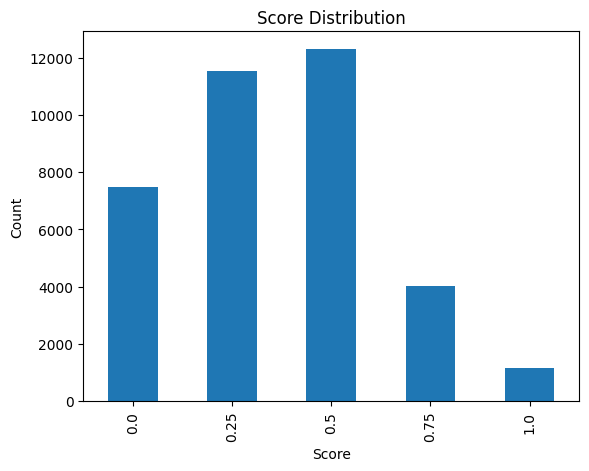

In [26]:
#This can be seen by below plot
import matplotlib.pyplot as plt

df['score'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Score Distribution')
plt.show()



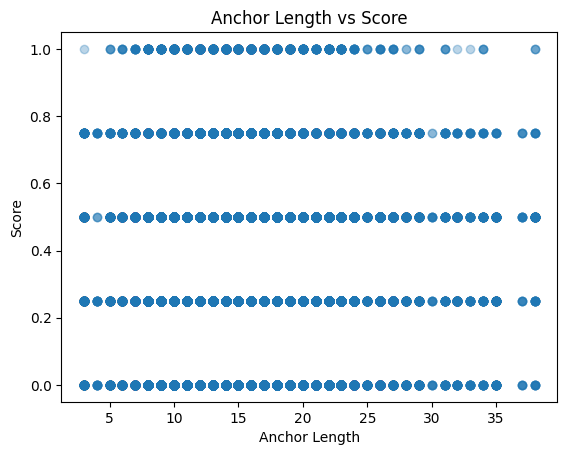

In [27]:
#Anchor text  length vs score
df['anchor_len'] = df['anchor'].apply(len)

plt.scatter(df['anchor_len'], df['score'], alpha=0.3)
plt.xlabel('Anchor Length')
plt.ylabel('Score')
plt.title('Anchor Length vs Score')
plt.show()

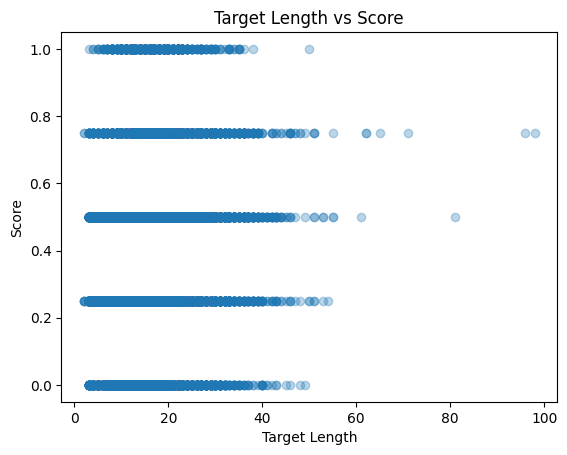

In [28]:
#target Text    vs Score
df['target_len'] = df['target'].apply(len)

plt.scatter(df['target_len'], df['score'], alpha=0.3)
plt.xlabel('Target Length')
plt.ylabel('Score')
plt.title('Target Length vs Score')
plt.show() 

In [29]:
def f(x): return -3*x**2 + 2*x + 20

In [30]:
import numpy as np, matplotlib.pyplot as plt

def plot_function(f, min=-2.1, max=2.1, color='r'):
    x = np.linspace(min,max, 100)[:,None]
    plt.plot(x, f(x), color)

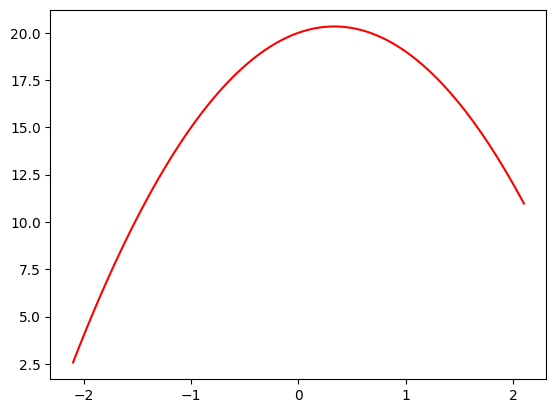

In [31]:
plot_function(f)


For instance, perhaps we've measured the height above ground of an object before and after some event. The measurements will have some random error. We can use numpy's random number generator to simulate that. I like to use seed when writing about simulations like this so that I know you'll see the same thing I do:

In [32]:
from numpy.random import normal,seed,uniform
np.random.seed(42)

In [33]:
#Here's a function add_noise that adds some random variation to an array
def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

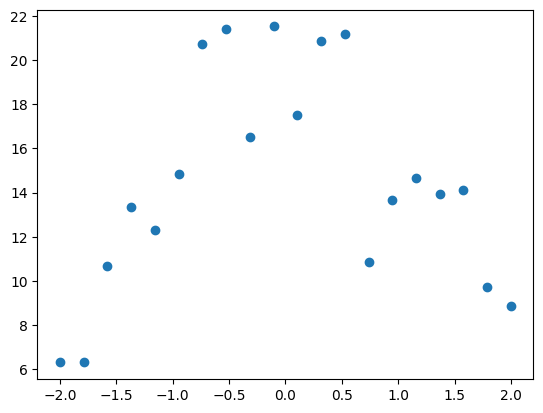

In [34]:
#Let's use it to simulate some measurements evenly distributed over time:
x = np.linspace(-2, 2, num=20)[:,None]
y = add_noise(f(x), 0.2, 1.3)
plt.scatter(x,y);


Now let's see what happens if we underfit or overfit these predictions. To do that, we'll create a function that fits a polynomial of some degree (e.g. a line is degree 1, quadratic is degree 2, cubic is degree 3, etc). 

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def plot_poly(degree):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x, y)
    plt.scatter(x,y)
    plot_function(model.predict)

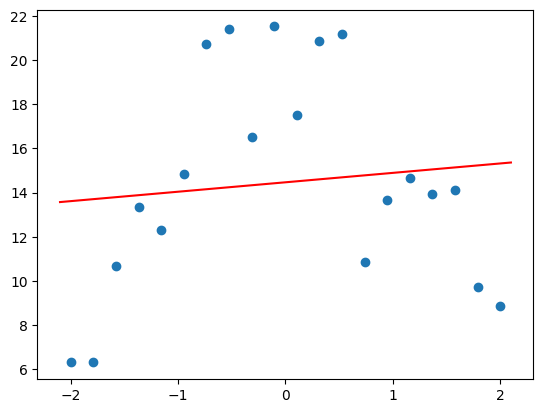

In [36]:
#So, what happens if we fit a line (a "degree 1 polynomial") to our measurements?
plot_poly(1)

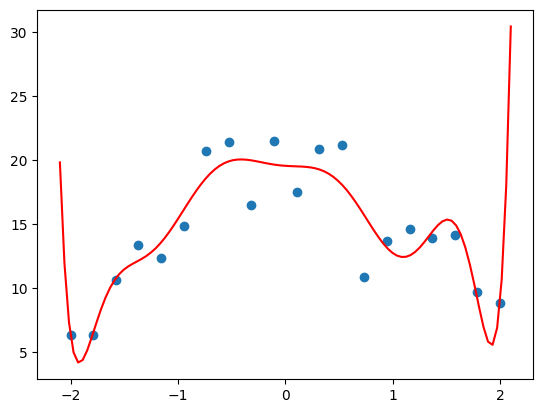

In [37]:
#As you see, the points on the red line (the line we fitted) aren't very close at all. This is under-fit -- there's not enough detail in our function to match our data.

#And what happens if we fit a degree 10 polynomial to our measurements?

plot_poly(10)

linkcode
Well now it fits our data better, but it doesn't look like it'll do a great job predicting points other than those we measured -- especially those in earlier or later time periods. This is over-fit -- there's too much detail such that the model fits our points, but not the underlying process we really care about.

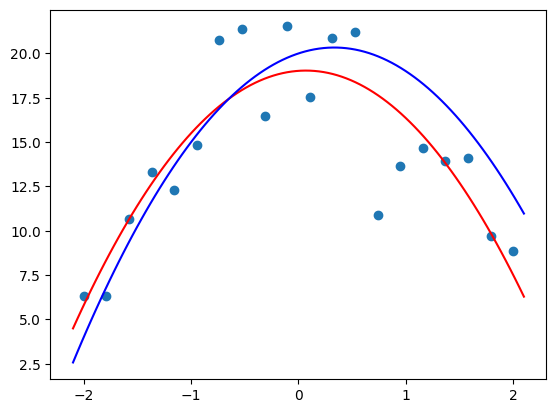

In [38]:
plot_poly(2)
plot_function(f, color='b')

So, how do we recognise whether our models are under-fit, over-fit, or "just right"? We use a validation set. This is a set of data that we "hold out" from training -- we don't let our model see it at all. If you use the fastai library, it automatically creates a validation set for you if you don't have one, and will always report metrics (measurements of the accuracy of a model) using the validation set.

The validation set is only ever used to see how we're doing. It's never used as inputs to training the model.

Transformers uses a DatasetDict for holding your training and validation sets. To create one that contains 25% of our data for the validation set, and 75% for the training set, use train_test_split:

In [39]:
dds = tok_ds.train_test_split(0.25, seed=42)
dds

DatasetDict({
    train: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27354
    })
    test: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9119
    })
})

Here validation set here is called test.
We'll use eval as our name for the test set, to avoid confusion with the test dataset that was created above.

In [40]:
eval_df['input'] = 'TEXT1: ' + eval_df.context + '; TEXT2: ' + eval_df.target + '; ANC1: ' + eval_df.anchor
eval_ds = Dataset.from_pandas(eval_df).map(tok_func, batched=True)

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

### Metrics and correlation

In [41]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
housing = housing['data'].join(housing['target']).sample(1000, random_state=52)
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7506,3.0550,37.0,5.152778,1.048611,729.0,5.062500,33.92,-118.28,1.054
4720,3.0862,35.0,4.697897,1.055449,1159.0,2.216061,34.05,-118.37,3.453
12888,2.5556,24.0,4.864905,1.129222,1631.0,2.395007,38.66,-121.35,1.057
13344,3.0057,32.0,4.212687,0.936567,1378.0,5.141791,34.05,-117.64,0.969
7173,1.9083,42.0,3.888554,1.039157,1535.0,4.623494,34.05,-118.19,1.192


In [42]:
np.set_printoptions(precision=2, suppress=True)

np.corrcoef(housing, rowvar=False)

array([[ 1.  , -0.12,  0.43, -0.08,  0.01, -0.07, -0.12,  0.04,  0.68],
       [-0.12,  1.  , -0.17, -0.06, -0.31,  0.  ,  0.03, -0.13,  0.12],
       [ 0.43, -0.17,  1.  ,  0.76, -0.09, -0.07,  0.12, -0.03,  0.21],
       [-0.08, -0.06,  0.76,  1.  , -0.08, -0.07,  0.09,  0.  , -0.04],
       [ 0.01, -0.31, -0.09, -0.08,  1.  ,  0.16, -0.15,  0.13,  0.  ],
       [-0.07,  0.  , -0.07, -0.07,  0.16,  1.  , -0.16,  0.17, -0.27],
       [-0.12,  0.03,  0.12,  0.09, -0.15, -0.16,  1.  , -0.93, -0.16],
       [ 0.04, -0.13, -0.03,  0.  ,  0.13,  0.17, -0.93,  1.  , -0.03],
       [ 0.68,  0.12,  0.21, -0.04,  0.  , -0.27, -0.16, -0.03,  1.  ]])


This works well when we're getting a bunch of values at once, but it's overkill when we want a single coefficient:

In [43]:
np.corrcoef(housing.MedInc, housing.MedHouseVal)

array([[1.  , 0.68],
       [0.68, 1.  ]])


Therefore, we'll create this little function to just return the single number we need given a pair of variables:

In [44]:
def corr(x,y): return np.corrcoef(x,y)[0][1]

corr(housing.MedInc, housing.MedHouseVal)

np.float64(0.6760250732906002)

In [45]:
def show_corr(df, a, b):
    x,y = df[a],df[b]
    plt.scatter(x,y, alpha=0.5, s=4)
    plt.title(f'{a} vs {b}; r: {corr(x, y):.2f}')

OK, let's check out the correlation between income and house value:

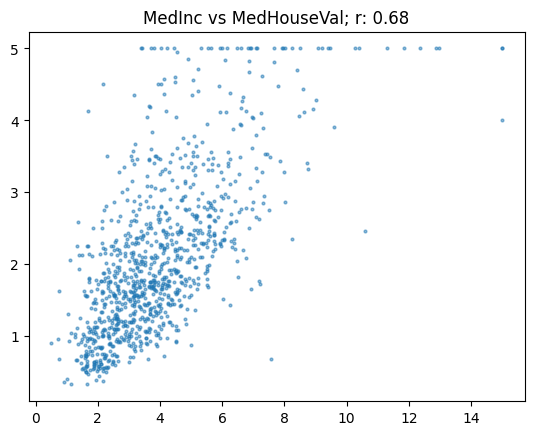

In [46]:
show_corr(housing, 'MedInc', 'MedHouseVal')


The relationship looks like it is similarly close to the previous example, but r is much lower than the income vs valuation case. Why is that? The reason is that there are a lot of outliers -- values of AveRooms well outside the mean.

r is very sensitive to outliers. If there's outliers in your data, then the relationship between them will dominate the metric. In this case, the houses with a very high number of rooms don't tend to be that valuable, so it's decreasing r from where it would otherwise be.

Let's remove the outliers and try again:

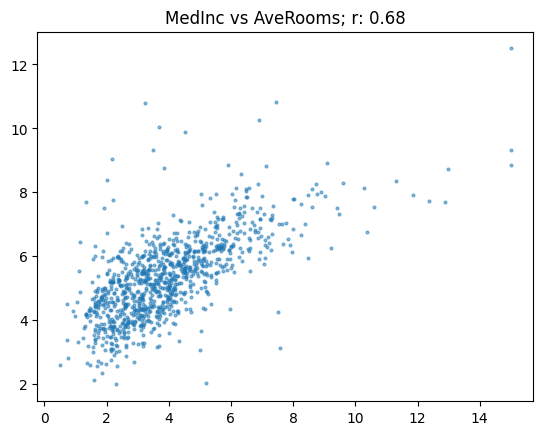

In [47]:
subset = housing[housing.AveRooms<15]
show_corr(subset, 'MedInc', 'AveRooms')

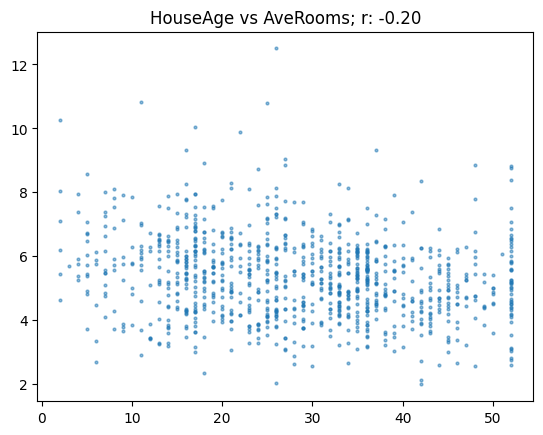

In [48]:
show_corr(subset, 'HouseAge', 'AveRooms')

As you see here, a correlation of -0.2 shows a very weak negative trend.

We've seen now examples of a variety of levels of correlation coefficient, so hopefully you're getting a good sense of what this metric means.

Transformers expects metrics to be returned as a dict, since that way the trainer knows what label to use, so let's create a function to do that:

In [49]:
def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}

### Training our model

In [50]:
from transformers import TrainingArguments,Trainer

In [77]:
eval_strategy="epoch"

Transformers uses the TrainingArguments class to set up arguments. Don't worry too much about the values we're using here -- they should generally work fine in most cases. It's just the 3 parameters above that you may need to change for different models.

In [58]:
!pip install 'accelerate>=1.1.0' --quiet

In [79]:
args = TrainingArguments('outputs', learning_rate=lr, warmup_steps=0.1, 
    lr_scheduler_type='cosine', fp16=False,
    eval_strategy="epoch", per_device_train_batch_size=bs, 
    per_device_eval_batch_size=bs*2,
    num_train_epochs=epochs, weight_decay=0.01, report_to='none')

We can now create our model, and Trainer, which is a class which combines the data and model together (just like Learner in fastai):

In [60]:
model_nm = 'microsoft/deberta-v3-small'

In [94]:
# Step 1 - fix learning rate
lr = 2e-5
bs = 16
epochs=4

# Step 2 - redefine args
args = TrainingArguments('outputs', learning_rate=lr, warmup_ratio=0.1, 
    lr_scheduler_type='cosine', fp16=False,
    eval_strategy="epoch", per_device_train_batch_size=bs, 
    per_device_eval_batch_size=bs*2,
    num_train_epochs=epochs, weight_decay=0.01, report_to='none')

# Step 3 - reinitialize model fresh
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=1)

# Step 4 - reinitialize trainer
trainer = Trainer(model, args, train_dataset=dds['train'], eval_dataset=dds['test'],
                  processing_class=tokz, compute_metrics=corr_d)

# Step 5 - train
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias       

Epoch,Training Loss,Validation Loss,Pearson
1,0.000000,nan,nan
2,0.000000,nan,nan
3,0.000000,nan,nan
4,0.000000,nan,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/manojkumar/venvs/jupyter/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=6840, training_loss=0.0734735059459307, metrics={'train_runtime': 869.8887, 'train_samples_per_second': 125.782, 'train_steps_per_second': 7.863, 'total_flos': 589231679226000.0, 'train_loss': 0.0734735059459307, 'epoch': 4.0})

Some weights of the model checkpoint at microsoft/deberta-v3-small were not used when initializing DebertaV2ForSequenceClassification: ['mask_predictions.dense.weight', 'mask_predictions.dense.bias', 'mask_predictions.LayerNorm.bias', 'lm_predictions.lm_head.dense.weight', 'mask_predictions.LayerNorm.weight', 'mask_predictions.classifier.bias', 'lm_predictions.lm_head.bias', 'lm_predictions.lm_head.LayerNorm.bias', 'mask_predictions.classifier.weight', 'lm_predictions.lm_head.LayerNorm.weight', 'lm_predictions.lm_head.dense.bias']
- This IS expected if you are initializing DebertaV2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaV2ForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['pooler.dense.weight', 'classifier.bias', 'pooler.dense.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using amp half precision backend

Look out - some of our predictions are <0, or >1! This once again shows the value of remember to actually look at your data. Let's fix those out-of-bounds predictions:

In [95]:
print(dds['test'].features)
print(dds['train'].features)

{'id': Value('large_string'), 'anchor': Value('large_string'), 'target': Value('large_string'), 'context': Value('large_string'), 'labels': Value('float64'), 'input': Value('large_string'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
{'id': Value('large_string'), 'anchor': Value('large_string'), 'target': Value('large_string'), 'context': Value('large_string'), 'labels': Value('float64'), 'input': Value('large_string'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [96]:
# Check actual label values in test set
import numpy as np
print(dds['test']['labels'][:10])
print(np.isnan(dds['test']['labels']).sum())

[0.25, 0.25, 0.0, 0.5, 0.5, 0.25, 0.25, 0.5, 0.0, 0.25]
0


In [101]:
# Step 1 - delete the corrupted model entirely
del model
del trainer

# Step 2 - clear cache
import torch
import gc
gc.collect()
torch.mps.empty_cache()

# Step 3 - fresh model
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=1)

# Step 4 - test immediately BEFORE any training
device = torch.device('cpu')
sample = dds['train'][0]
inputs = {k: torch.tensor([v]).to(device) for k, v in sample.items() 
          if k in ['input_ids', 'attention_mask', 'token_type_ids']}

with torch.no_grad():
    output = model.to(device)(**inputs)
print(output.logits)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias       

tensor([[0.0997]], dtype=torch.float16)


In [97]:
preds = trainer.predict(dds['test'])
print(preds.predictions[:10])
print(preds.label_ids[:10])

[nan nan nan nan nan nan nan nan nan nan]
[0.25 0.25 0.   0.5  0.5  0.25 0.25 0.5  0.   0.25]


In [102]:
preds = trainer.predict(eval_ds).predictions.astype(float)
preds

NameError: name 'trainer' is not defined

In [93]:
#Let's get some predictions on the test set:
preds = np.clip(preds, 0, 1)
preds

array([[nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan]])